In [265]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import f_classif
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt
import seaborn as sns

## Data Loading and Overview

In [266]:
metadata = pd.read_csv('data/metadata.csv', index_col=0)
metadata.index_name = 'Patient_ID'
metadata

,Age,Gender,Smoking_History,Tumor_Size_mm,Histological_Grade,Lymph_Node_Involvement,Metastasis,Treatment,Response_to_Treatment,Follow_up_Duration_months,Survival_Status,Family_History_of_Cancer,Ethnicity
Patient_ID,,,,,,,,,,,,,
BC.1,70,Male,No,31,Low,No,No,Surgery,Complete Remission,25,Survived,No,Caucasian
BC.2,54,Male,Yes,34,Intermediate,No,No,Combination,Complete Remission,40,Survived,Yes,Hispanic
BC.3,53,Male,Yes,39,Intermediate,Yes,No,Chemotherapy,Complete Remission,19,Survived,No,African-American
BC.4,42,Male,No,31,Low,No,No,Radiation,Complete Remission,42,Survived,Yes,Other
BC.5,81,Male,Yes,34,Intermediate,Yes,No,Surgery,Complete Remission,60,Survived,No,Caucasian
...,...,...,...,...,...,...,...,...,...,...,...,...,...
BC.136,50,Male,Yes,127,High,No,No,Radiation,Progressive Disease,56,Deceased,No,Caucasian
BC.137,75,Female,Yes,104,High,No,Yes,Surgery,Partial Remission,18,Deceased,No,Caucasian
BC.138,83,Female,No,143,Low,Yes,No,Radiation,Progressive Disease,55,Deceased,No,Asian


In [267]:
protein_data = pd.read_csv('data/proteomics.txt', header=0, index_col=0, sep='\t').T
protein_data.index_name = 'Patient_ID'
protein_data

Protein_ID,A1BG,A2M,AAMDC,AARS1,AASDHPPT,AASS,ABAT,ABCC4,ABCE1,ABCF1,...,YWHAE,YWHAG,YWHAH,YWHAQ,YWHAZ,ZADH2,ZFHX3,ZNF185,ZNF207,ZYX
BC.1,1.047640e+09,1.304314e+10,35395800.00,77138600.00,1322772.000,2.149774e+07,1.615196e+07,2294820.000,1.101012e+07,24670800.00,...,2.717220e+09,7.508160e+08,577654000.0,1.149346e+09,7.624540e+09,9.264420e+06,4.984337e+05,1.496858e+07,1.708168e+07,102436400.0
BC.2,1.113700e+09,6.184000e+09,58690000.00,96508000.00,9252077.742,3.165600e+06,8.644212e+06,1917313.735,1.235980e+07,8326600.00,...,1.876420e+09,8.162600e+08,480040000.0,1.047000e+09,6.705200e+09,2.910213e+06,3.593441e+05,4.789986e+05,1.293843e+06,292820000.0
BC.3,1.055760e+09,6.564800e+09,9091800.00,46406000.00,3913600.000,4.620000e+06,4.325549e+06,3463000.000,2.843400e+06,7310400.00,...,1.758920e+09,1.137120e+09,697180000.0,1.359340e+09,8.877000e+09,1.543817e+06,6.227843e+05,3.823402e+05,3.410526e+06,168724000.0
BC.4,1.104000e+09,4.329400e+09,41908000.00,17550000.00,1687937.466,5.226863e+06,7.219093e+06,3200134.601,1.423474e+06,6473600.00,...,1.184080e+09,6.620400e+08,473080000.0,7.363200e+08,3.372000e+09,2.494988e+06,3.323255e+05,4.357254e+05,1.235035e+07,651260000.0
BC.5,1.158380e+09,9.797400e+09,39804000.00,56650000.00,5560375.423,9.672200e+06,8.832000e+06,5298370.284,7.971200e+06,7818800.00,...,2.570000e+09,7.799800e+08,419820000.0,1.485820e+09,7.733800e+09,5.560051e+05,8.482400e+07,4.351219e+05,1.137900e+07,213560000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
BC.136,1.060922e+09,9.254695e+09,39653134.70,47078585.81,4646577.381,1.205269e+07,1.250407e+07,5985181.092,6.624340e+06,13245682.25,...,1.527129e+09,5.248372e+08,291284890.4,6.644021e+08,4.191205e+09,3.352999e+06,3.594246e+07,7.468710e+06,9.313667e+06,312958883.9
BC.137,9.211745e+08,8.989629e+09,42055883.58,44975411.69,4703299.970,1.210398e+07,1.246855e+07,6126325.965,6.627933e+06,13307683.82,...,1.546514e+09,5.514091e+08,290966152.7,6.577622e+08,4.196481e+09,3.786910e+06,4.663867e+07,7.140596e+06,1.158332e+07,262692872.1
BC.138,9.034938e+08,9.166813e+09,39200243.47,47029104.10,5754406.976,8.733812e+06,9.521226e+06,5979016.627,6.743236e+06,12100032.37,...,1.506076e+09,5.192202e+08,276745659.8,6.582320e+08,4.201648e+09,2.621293e+06,3.853201e+07,7.737410e+06,9.407731e+06,263100145.2
BC.139,9.445144e+08,8.404558e+09,39613364.26,44595944.29,4575239.221,8.581587e+06,9.550733e+06,8766175.378,6.685868e+06,12645010.21,...,1.643239e+09,5.201992e+08,276991147.1,6.572683e+08,4.189549e+09,2.982408e+06,3.607037e+07,8.751533e+06,1.094825e+07,266445555.3


In [268]:
clusters = pd.read_csv("clusters.csv")
clusters.index_name = 'Patient_ID'
clusters

,Patient_ID,Cluster_id,Cluster_clinical
0,BC.1,0,Tis
1,BC.2,0,Tis
2,BC.3,0,Tis
3,BC.4,0,Tis
4,BC.5,0,Tis
...,...,...,...
135,BC.136,6,T4
136,BC.137,6,T4
137,BC.138,6,T4
138,BC.139,6,T4


In [269]:
df = protein_data.merge(clusters, left_index=True, right_on="Patient_ID", how="inner").set_index("Patient_ID")

In [270]:
df

,A1BG,A2M,AAMDC,AARS1,AASDHPPT,AASS,ABAT,ABCC4,ABCE1,ABCF1,...,YWHAH,YWHAQ,YWHAZ,ZADH2,ZFHX3,ZNF185,ZNF207,ZYX,Cluster_id,Cluster_clinical
Patient_ID,,,,,,,,,,,,,,,,,,,,,
BC.1,1.047640e+09,1.304314e+10,35395800.00,77138600.00,1322772.000,2.149774e+07,1.615196e+07,2294820.000,1.101012e+07,24670800.00,...,577654000.0,1.149346e+09,7.624540e+09,9.264420e+06,4.984337e+05,1.496858e+07,1.708168e+07,102436400.0,0,Tis
BC.2,1.113700e+09,6.184000e+09,58690000.00,96508000.00,9252077.742,3.165600e+06,8.644212e+06,1917313.735,1.235980e+07,8326600.00,...,480040000.0,1.047000e+09,6.705200e+09,2.910213e+06,3.593441e+05,4.789986e+05,1.293843e+06,292820000.0,0,Tis
BC.3,1.055760e+09,6.564800e+09,9091800.00,46406000.00,3913600.000,4.620000e+06,4.325549e+06,3463000.000,2.843400e+06,7310400.00,...,697180000.0,1.359340e+09,8.877000e+09,1.543817e+06,6.227843e+05,3.823402e+05,3.410526e+06,168724000.0,0,Tis
BC.4,1.104000e+09,4.329400e+09,41908000.00,17550000.00,1687937.466,5.226863e+06,7.219093e+06,3200134.601,1.423474e+06,6473600.00,...,473080000.0,7.363200e+08,3.372000e+09,2.494988e+06,3.323255e+05,4.357254e+05,1.235035e+07,651260000.0,0,Tis
BC.5,1.158380e+09,9.797400e+09,39804000.00,56650000.00,5560375.423,9.672200e+06,8.832000e+06,5298370.284,7.971200e+06,7818800.00,...,419820000.0,1.485820e+09,7.733800e+09,5.560051e+05,8.482400e+07,4.351219e+05,1.137900e+07,213560000.0,0,Tis
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
BC.136,1.060922e+09,9.254695e+09,39653134.70,47078585.81,4646577.381,1.205269e+07,1.250407e+07,5985181.092,6.624340e+06,13245682.25,...,291284890.4,6.644021e+08,4.191205e+09,3.352999e+06,3.594246e+07,7.468710e+06,9.313667e+06,312958883.9,6,T4
BC.137,9.211745e+08,8.989629e+09,42055883.58,44975411.69,4703299.970,1.210398e+07,1.246855e+07,6126325.965,6.627933e+06,13307683.82,...,290966152.7,6.577622e+08,4.196481e+09,3.786910e+06,4.663867e+07,7.140596e+06,1.158332e+07,262692872.1,6,T4
BC.138,9.034938e+08,9.166813e+09,39200243.47,47029104.10,5754406.976,8.733812e+06,9.521226e+06,5979016.627,6.743236e+06,12100032.37,...,276745659.8,6.582320e+08,4.201648e+09,2.621293e+06,3.853201e+07,7.737410e+06,9.407731e+06,263100145.2,6,T4


In [271]:
y = df["Cluster_clinical"]
X = df.drop(columns=["Cluster_id", "Cluster_clinical"])

In [272]:
scaler = StandardScaler()

## log-transformation followed by z-scoring per protein

In [273]:
X_log = np.log2(X + 1)
X_z = scaler.fit_transform(X_log)
X_z = pd.DataFrame(X_z, index=X_log.index, columns=X_log.columns)

## ANOVA F-statistics

In [274]:
F, p = f_classif(X_z, y)
rank = pd.DataFrame({"protein": X_z.columns, "F": F, "p": p}).sort_values("F", ascending=False)

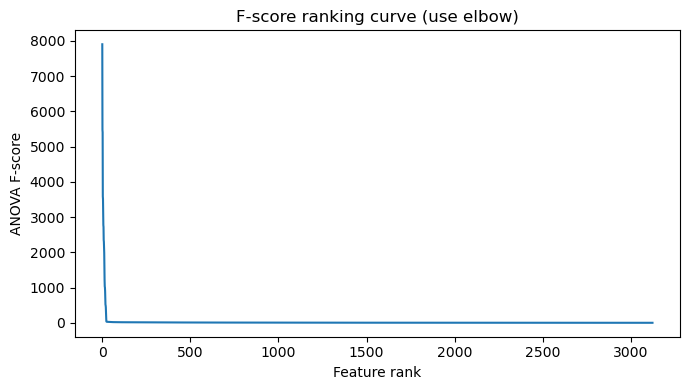

In [275]:
plt.figure(figsize=(7,4))
plt.plot(np.arange(1, len(rank)+1), rank["F"].values)
plt.xlabel("Feature rank")
plt.ylabel("ANOVA F-score")
plt.title("F-score ranking curve (use elbow)")
plt.tight_layout()
plt.show()


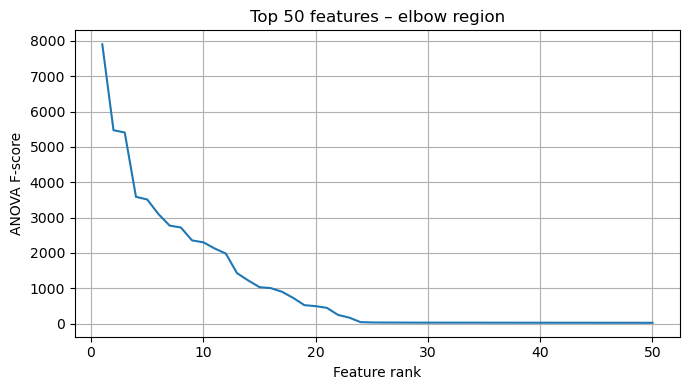

In [276]:
plt.figure(figsize=(7,4))
plt.plot(np.arange(1, 51), rank["F"].values[:50])
plt.xlabel("Feature rank")
plt.ylabel("ANOVA F-score")
plt.title("Top 50 features – elbow region")
plt.tight_layout()
plt.grid()
plt.show()

In [277]:
N = 25
features_anova = rank["protein"].head(N).tolist()

To identify discriminative proteins between bladder cancer stages, we ranked all proteins using a multiclass ANOVA F-test.
The F-score ranking curve revealed a steep decrease among the top-ranked proteins followed by a clear flattening of the curve.
An elbow was observed around ranks 20–30, indicating diminishing returns beyond this point.
Therefore, we selected the top 25 proteins as a minimal yet informative feature set for downstream stage-specific analysis.

## RF check

In [278]:
rf = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_z, y)

rf_imp = pd.DataFrame({
    "protein": X_z.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

In [279]:
top_rf_25 = set(rf_imp.head(25)["protein"])
top_anova_25 = set(rank.head(25)["protein"])
overlap_25 = len(top_rf_25 & top_anova_25)

print("Overlap between top 25 (RF) and top 25 (ANOVA):", overlap_25)

Overlap between top 25 (RF) and top 25 (ANOVA): 23


Proteins were ranked using ANOVA F-statistics, and the number of selected features was determined using the elbow criterion.
Random Forest feature importance was used as a robustness check, revealing a high overlap with the ANOVA-based ranking, indicating that the selected features are not method-dependent.

In [280]:
stage_order = ["Tis", "Ta", "T1", "T2a", "T2b", "T3", "T4"]

features = features_anova
X_sel = X_z[features]
mean_z = X_sel.groupby(y).mean()

In [281]:
mean_z

,MAPT,MMP14,S100A9,CXCR4,ANXA1,GADD45A,MYC,SPP1,CDKN1A,FOXM1,...,ITGA5,FGFR3,CTNNB1,CCNE1,CCNB1,APOE,TFRC,FN1,LTBP1,GATAD2A
Cluster_clinical,,,,,,,,,,,,,,,,,,,,,
T1,0.296537,2.376097,2.219385,1.314986,2.398486,-0.681041,0.238837,-0.218168,-0.188540,-0.132962,...,-0.128993,-0.170451,0.346742,-0.844069,-0.906225,0.390209,-0.703558,0.425739,0.179807,0.095438
T2a,-0.240794,-0.364453,-0.541162,-0.774454,-0.238276,-0.715173,0.807461,0.068002,-0.627050,-0.642987,...,-0.251588,-1.135161,-0.543965,1.549802,1.608384,-0.416271,1.863210,-0.420422,0.501951,0.540610
T2b,2.155739,-0.026242,0.397942,-0.110548,-0.270076,-0.472584,1.904489,-0.693880,-0.602491,-0.448213,...,-0.064171,-0.931463,-0.113531,0.720984,-0.235338,-0.849623,-0.264278,-0.399080,0.281133,0.276074
T3,-0.321374,-0.428146,0.080924,-0.761981,-0.389873,-0.773772,-0.314755,0.364634,0.675656,-0.683304,...,2.342839,0.193261,-0.679931,0.696037,1.194136,-0.935590,0.654405,1.874068,0.444071,0.474723
T4,0.062514,-0.703331,-0.784424,-0.794060,-0.789797,-0.462939,-0.689732,2.190222,2.162769,-1.080030,...,-0.594056,-0.733138,-0.875878,-1.560065,-1.316226,-0.266140,-1.284922,0.249142,0.625982,0.632355
Ta,-0.681565,-0.153250,-0.562703,1.740032,-0.204406,1.311354,-0.709014,-0.765283,-0.719068,1.173393,...,-0.461381,1.059878,2.235659,-0.240915,-0.079810,2.160399,0.232887,-1.409276,-0.153127,-0.286394
Tis,-1.271056,-0.700675,-0.809963,-0.613976,-0.506057,1.794155,-1.237285,-0.945526,-0.701276,1.814103,...,-0.842650,1.717074,-0.369095,-0.321775,-0.264922,-0.082985,-0.497744,-0.320172,-1.879817,-1.732808


In [282]:
mean_z = mean_z.reindex([s for s in stage_order])

In [283]:
mean_z

,MAPT,MMP14,S100A9,CXCR4,ANXA1,GADD45A,MYC,SPP1,CDKN1A,FOXM1,...,ITGA5,FGFR3,CTNNB1,CCNE1,CCNB1,APOE,TFRC,FN1,LTBP1,GATAD2A
Cluster_clinical,,,,,,,,,,,,,,,,,,,,,
Tis,-1.271056,-0.700675,-0.809963,-0.613976,-0.506057,1.794155,-1.237285,-0.945526,-0.701276,1.814103,...,-0.842650,1.717074,-0.369095,-0.321775,-0.264922,-0.082985,-0.497744,-0.320172,-1.879817,-1.732808
Ta,-0.681565,-0.153250,-0.562703,1.740032,-0.204406,1.311354,-0.709014,-0.765283,-0.719068,1.173393,...,-0.461381,1.059878,2.235659,-0.240915,-0.079810,2.160399,0.232887,-1.409276,-0.153127,-0.286394
T1,0.296537,2.376097,2.219385,1.314986,2.398486,-0.681041,0.238837,-0.218168,-0.188540,-0.132962,...,-0.128993,-0.170451,0.346742,-0.844069,-0.906225,0.390209,-0.703558,0.425739,0.179807,0.095438
T2a,-0.240794,-0.364453,-0.541162,-0.774454,-0.238276,-0.715173,0.807461,0.068002,-0.627050,-0.642987,...,-0.251588,-1.135161,-0.543965,1.549802,1.608384,-0.416271,1.863210,-0.420422,0.501951,0.540610
T2b,2.155739,-0.026242,0.397942,-0.110548,-0.270076,-0.472584,1.904489,-0.693880,-0.602491,-0.448213,...,-0.064171,-0.931463,-0.113531,0.720984,-0.235338,-0.849623,-0.264278,-0.399080,0.281133,0.276074
T3,-0.321374,-0.428146,0.080924,-0.761981,-0.389873,-0.773772,-0.314755,0.364634,0.675656,-0.683304,...,2.342839,0.193261,-0.679931,0.696037,1.194136,-0.935590,0.654405,1.874068,0.444071,0.474723
T4,0.062514,-0.703331,-0.784424,-0.794060,-0.789797,-0.462939,-0.689732,2.190222,2.162769,-1.080030,...,-0.594056,-0.733138,-0.875878,-1.560065,-1.316226,-0.266140,-1.284922,0.249142,0.625982,0.632355


In [284]:
thr = 0.25
elev = (mean_z > thr).astype(int)


thr_down = -0.25
down = (mean_z < thr_down).astype(int)

In [285]:
def earliest_stage_idx(feature):
    for stage in stage_order:
        if elev.loc[stage, feature] == 1:
            return stage_order.index(stage)
    return 999

sorted_features = sorted(features, key=earliest_stage_idx)

mean_z_sorted = mean_z[sorted_features]
elev_sorted = elev[sorted_features]
down_sorted = down[sorted_features]

In [286]:
elev_sorted

,GADD45A,FOXM1,CCNA2,UPK3A,FGFR3,CXCR4,CTNNB1,APOE,MAPT,MMP14,...,CCNE1,CCNB1,TFRC,LTBP1,GATAD2A,SPP1,CDKN1A,SERPINE1,NRP1,ITGA5
Cluster_clinical,,,,,,,,,,,,,,,,,,,,,
Tis,1,1,1,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Ta,1,1,1,0,1,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
T1,0,0,0,0,0,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
T2a,0,0,0,0,0,0,0,0,0,0,...,1,1,1,1,1,0,0,0,0,0
T2b,0,0,0,0,0,0,0,0,1,0,...,1,0,0,1,1,0,0,0,0,0
T3,0,0,0,1,0,0,0,0,0,0,...,1,1,1,1,1,1,1,1,1,1
T4,0,0,0,1,0,0,0,0,0,0,...,0,0,0,1,1,1,1,1,1,0


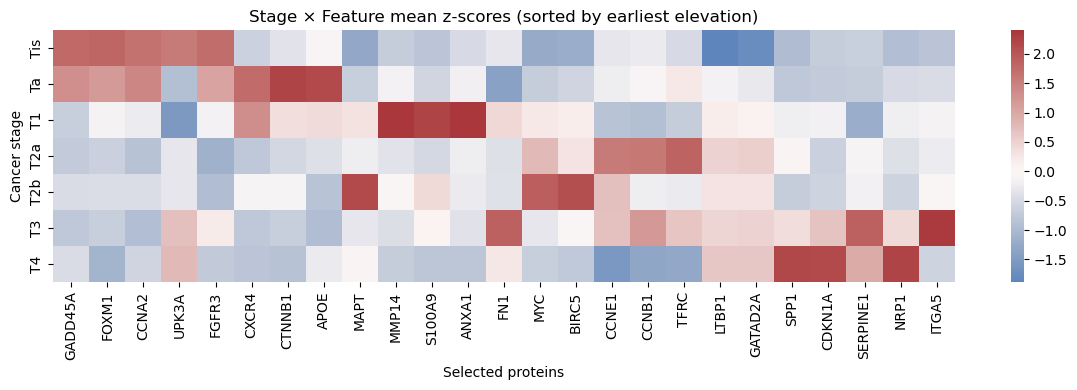

In [287]:
plt.figure(figsize=(12,4))
sns.heatmap(mean_z_sorted, cmap="vlag", center=0)
plt.title("Stage × Feature mean z-scores (sorted by earliest elevation)")
plt.xlabel("Selected proteins")
plt.ylabel("Cancer stage")
plt.tight_layout()
plt.show()

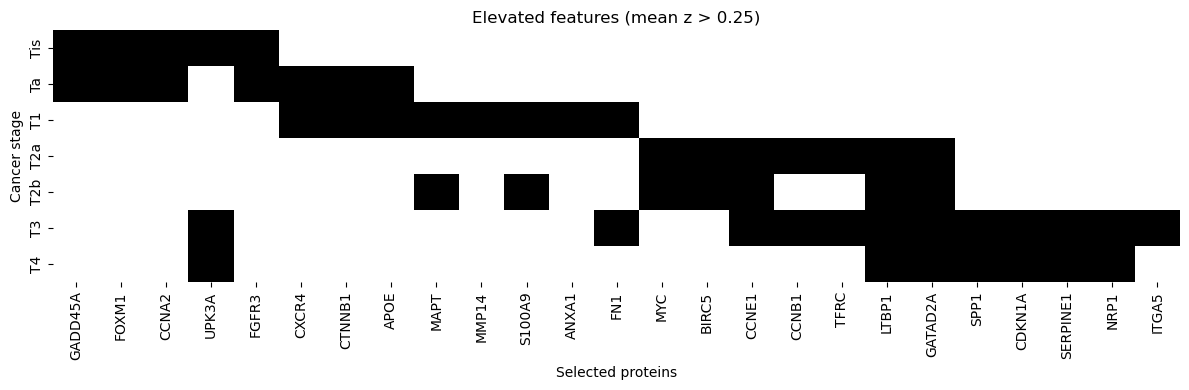

In [288]:
plt.figure(figsize=(12,4))
sns.heatmap(elev_sorted, cmap="Greys", cbar=False)
plt.title(f"Elevated features (mean z > {thr})")
plt.xlabel("Selected proteins")
plt.ylabel("Cancer stage")
plt.tight_layout()
plt.show()

In [290]:
state = pd.DataFrame("neutral", index=mean_z_sorted.index, columns=mean_z_sorted.columns)
state[elev_sorted == 1] = "up"
state[down_sorted == 1] = "down"

state.to_csv("stage_feature_summary_state.csv")
display(state)

,GADD45A,FOXM1,CCNA2,UPK3A,FGFR3,CXCR4,CTNNB1,APOE,MAPT,MMP14,...,CCNE1,CCNB1,TFRC,LTBP1,GATAD2A,SPP1,CDKN1A,SERPINE1,NRP1,ITGA5
Cluster_clinical,,,,,,,,,,,,,,,,,,,,,
Tis,up,up,up,up,up,down,down,neutral,down,down,...,down,down,down,down,down,down,down,down,down,down
Ta,up,up,up,down,up,up,up,up,down,neutral,...,neutral,neutral,neutral,neutral,down,down,down,down,down,down
T1,down,neutral,neutral,down,neutral,up,up,up,up,up,...,down,down,down,neutral,neutral,neutral,neutral,down,neutral,neutral
T2a,down,down,down,down,down,down,down,down,neutral,down,...,up,up,up,up,up,neutral,down,neutral,down,down
T2b,down,down,down,down,down,neutral,neutral,down,up,neutral,...,up,neutral,down,up,up,down,down,neutral,down,neutral
T3,down,down,down,up,neutral,down,down,down,down,down,...,up,up,up,up,up,up,up,up,up,up
T4,down,down,down,up,down,down,down,down,neutral,down,...,down,down,down,up,up,up,up,up,up,down
